# IND320 Compulsory Assignment 1

## Project links

- **GitHub repository:** https://github.com/VasiliiAnderson/ind320-project
- **Streamlit app:** https://vasilii-ind320.streamlit.app/

## Task description

#### GitHub and Streamlit.app accounts

- Prepare a GitHub account and create a public repository for your project work. Addresses on streamlit.app must be unique, so include your GitHub username or similar in the repository name. Report the Streamlit address and GitHub repository address in the Jupyter Notebook.
- Log in to [share.streamlit.io](https://share.streamlit.io/) using your GitHub account.
- Create a minimum working example of a Streamlit app, push it to GitHub, and ensure it works at `https://[yourproject].streamlit.app/`

#### Jupyter Notebook

- Read the `reservoirs.csv` file using Pandas (located in `D2Dbook/data`).
- Rename headers to English and understandable.
- Print its contents in a relevant way.
- Plot each column separately.
- Plot all columns together. Consider how to make this natural, given that the scales are different.
- Remember to fill in the log and AI usage mentioned in the General section above.

#### Streamlit app

- Create a Streamlit app including:
  - `requirements.txt` or `uv.lock` for package dependencies.
  - Four pages with dummy headers and test content for now, using separate `.py` files:
    1. The front/home page should have a sidebar menu with navigation options to the other pages.
    2. On the second page:
       - A table showing the imported data.
       - Use the row-wise `LineChartColumn()` to display the first month of the data series.
       - There should be one row in the table for each column of the imported data.
    3. On the third page:
       - A plot of the imported data, including a header, axis titles, and other relevant formatting.
       - A drop-down menu using `st.selectbox` for choosing any single column in the CSV or all columns together.
       - A selection slider using `st.select_slider` to select a subset of the months. The default should be the first month.
  - Data should be read from a local CSV file (`reservoirs.csv`), using caching for app speed.
  - In part 2 of the project, the local CSV file will be removed and MongoDB will be used instead.

#### Screencast

- Create a 5-minute screencast where you briefly showcase the running app and explain what the code does.

## 1. Setup and Imports

In [37]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Data Loading

In [38]:
# Defining the path to the CSV file relative to this notebook
data_path = Path("../data/reservoirs.csv")

# Loading the reservoir dataset into a Pandas DataFrame
df = pd.read_csv(data_path)

# Previewing the original dataset and column names
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 4. Data Preparation

In [39]:
# Renaming the original Norwegian column headers to clear English names
column_names = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_fill_level",
    "endring_fyllingsgrad": "change_in_fill_level",
}

df = df.rename(columns=column_names)

In [40]:
# Convert the observation date to a datetime variable
df["date"] = pd.to_datetime(df["date"])

# The dataset uses year 0001 as a placeholder when no next publication
# date is available. Replace these placeholder values with missing values.
df["next_publication_date"] = df["next_publication_date"].replace(
    "0001-01-01T00:00:00",
    pd.NA
)

# Convert valid publication dates to datetime
df["next_publication_date"] = pd.to_datetime(
    df["next_publication_date"],
    errors="coerce"
)

In [41]:
# Sort observations chronologically and by geographical area
df = (
    df
    .sort_values(["date", "area_type", "area_number"])
    .reset_index(drop=True)
)

## 5. Data Exploration

In [42]:
# Display the first observations after preprocessing
display(df.head(10))

,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,change_in_fill_level
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,NaT,0.734888,-0.113421
1,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,NaT,0.777604,-0.146657
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,NaT,0.596027,0.006349
3,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,NaT,0.801348,-0.242484
4,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,NaT,0.614288,0.002160
5,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,NaT,0.752703,-0.144430
6,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,NaT,0.798825,-0.162787
7,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,NaT,0.744693,-0.135837
8,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,NaT,0.661432,-0.094525
9,1995-01-15,EL,1,1995,2,0.583100,6.003264,3.500502,NaT,0.621467,-0.038367


In [43]:
# Inspect column types, missing values and dataset dimensions
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14877 non-null  datetime64[us]
 1   area_type                 14877 non-null  str           
 2   area_number               14877 non-null  int64         
 3   iso_year                  14877 non-null  int64         
 4   iso_week                  14877 non-null  int64         
 5   fill_level                14877 non-null  float64       
 6   capacity_twh              14877 non-null  float64       
 7   stored_energy_twh         14877 non-null  float64       
 8   next_publication_date     3555 non-null   datetime64[us]
 9   previous_week_fill_level  14877 non-null  float64       
 10  change_in_fill_level      14877 non-null  float64       
dtypes: datetime64[us](2), float64(5), int64(3), str(1)
memory usage: 1.3 MB


In [44]:
# Summarise the numerical variables
display(df.describe())

,date,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level,change_in_fill_level
count,14877,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000,3555,14877.000000,14877.000000
mean,2010-11-07 00:00:00,2.333333,2010.346038,26.405929,0.618852,29.145860,18.139713,2022-12-07 13:21:52.405063,0.618890,-0.000038
min,1995-01-08 00:00:00,0.000000,1995.000000,1.000000,0.055160,6.003264,0.331142,2019-02-27 13:00:00,0.055160,-0.242484
25%,2002-12-08 00:00:00,1.000000,2002.000000,13.000000,0.456234,17.390587,7.321973,2021-01-13 13:00:00,0.456356,-0.022395
50%,2010-11-07 00:00:00,2.000000,2010.000000,26.000000,0.648049,23.237715,14.501389,2022-12-07 13:00:00,0.648114,-0.007072
75%,2018-10-07 00:00:00,3.000000,2018.000000,39.000000,0.802135,34.043590,22.203530,2024-10-30 13:00:00,0.802133,0.016277
max,2026-09-06 00:00:00,5.000000,2026.000000,53.000000,1.020072,87.437580,84.544820,2026-09-16 13:00:00,1.020037,0.336623
std,NaN,1.490762,9.146696,15.017910,0.214850,22.739070,15.966211,NaN,0.214843,0.031385


The dataset contains 14,877 observations and 11 variables. The observations 
cover several geographical aggregation levels and span from 1995 to 2026. 
The numerical variables include reservoir fill level, storage capacity, 
stored energy and weekly changes in reservoir levels.

## 6. Individual Plots

The numerical reservoir measurements are plotted separately against time to inspect their development and variation.

### Numerical measurements

The dataset contains observations for several geographical aggregation levels. 
To avoid mixing different areas within the same time series, the plots below 
use the national observations (`area_type = "NO"` and `area_number = 0`). 
Each numerical measurement is plotted separately over time.

In [46]:
# Inspect the combinations of geographical area types and area numbers
df[["area_type", "area_number"]].drop_duplicates().sort_values(
    ["area_type", "area_number"]
)

,area_type,area_number
0,EL,1
1,EL,2
2,EL,3
3,EL,4
4,EL,5
5,NO,0
6,VASS,1
7,VASS,2
8,VASS,3


In [47]:
# Use national observations to avoid mixing several geographical
# aggregation levels within the same time series
norway_data = (
    df[
        (df["area_type"] == "NO")
        & (df["area_number"] == 0)
    ]
    .sort_values("date")
)

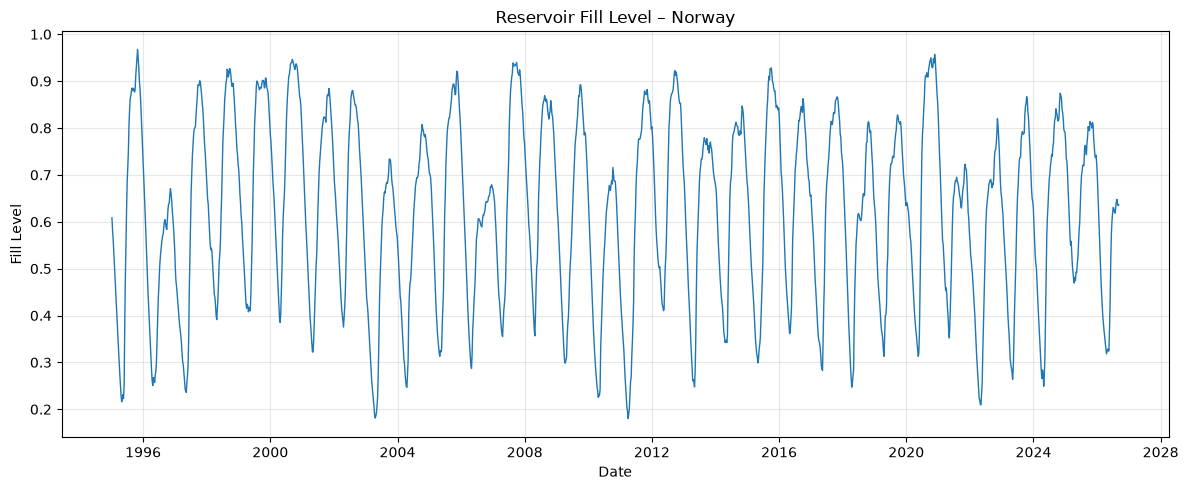

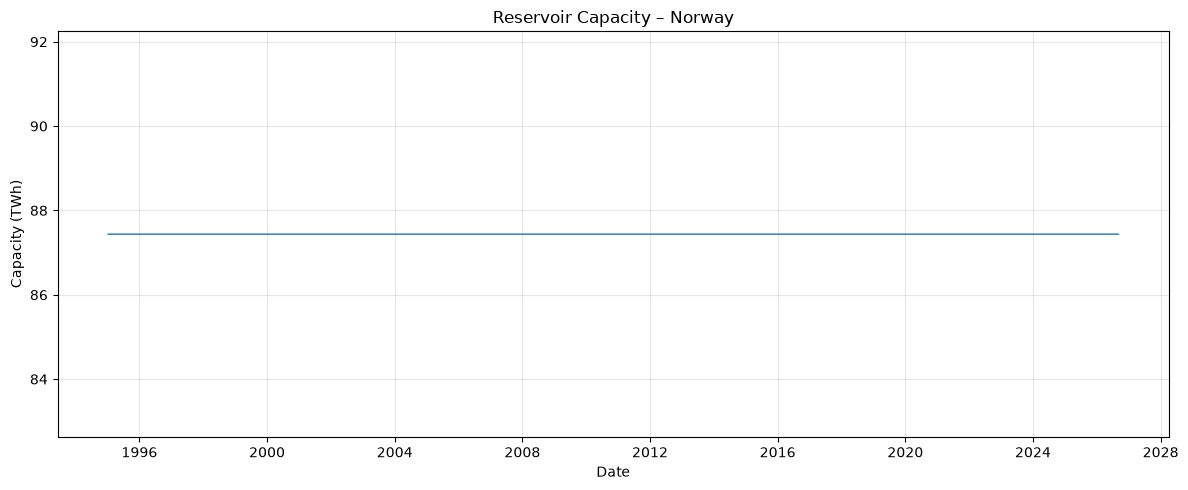

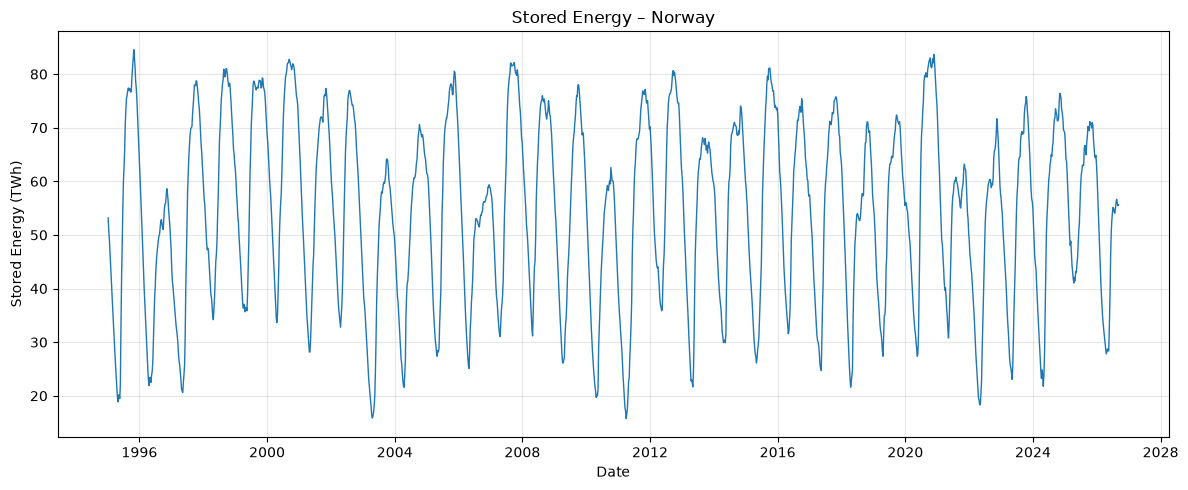

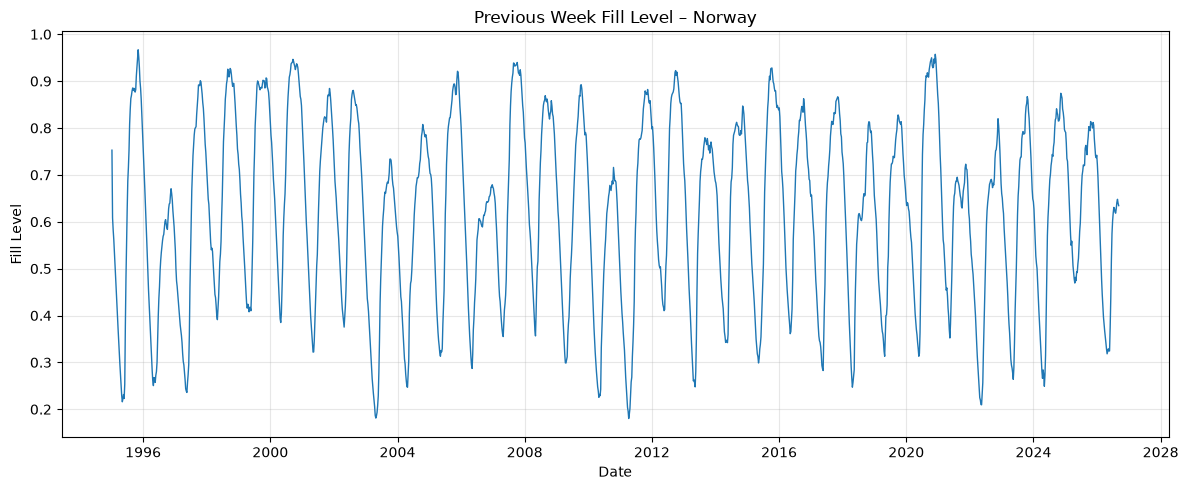

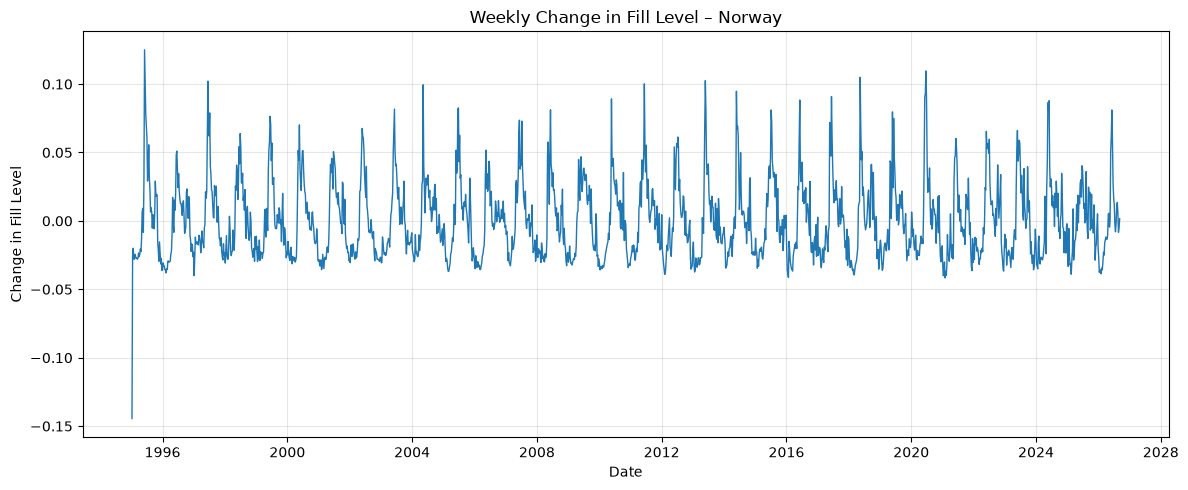

In [48]:
# Define informative titles and axis labels for each reservoir measurement
plot_info = {
    "fill_level": ("Reservoir Fill Level – Norway", "Fill Level"),
    "capacity_twh": ("Reservoir Capacity – Norway", "Capacity (TWh)"),
    "stored_energy_twh": ("Stored Energy – Norway", "Stored Energy (TWh)"),
    "previous_week_fill_level": (
        "Previous Week Fill Level – Norway",
        "Fill Level"
    ),
    "change_in_fill_level": (
        "Weekly Change in Fill Level – Norway",
        "Change in Fill Level"
    ),
}

# Plot each numerical reservoir measurement as a separate time series
for column, (title, ylabel) in plot_info.items():
    plt.figure(figsize=(12, 5))

    plt.plot(
        norway_data["date"],
        norway_data[column],
        linewidth=1
    )

    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [49]:
# Check whether national reservoir capacity changes over time
print("Number of unique values:", norway_data["capacity_twh"].nunique())
print("Minimum:", norway_data["capacity_twh"].min())
print("Maximum:", norway_data["capacity_twh"].max())

Number of unique values: 1
Minimum: 87.43758
Maximum: 87.43758


The national `capacity_twh` variable contains only one unique value. It is 
therefore useful as descriptive information, but it does not contain a 
time-varying pattern to compare with the other measurements.

### Categorical and time-related variables

The remaining columns mainly describe geographical areas and time identifiers rather than continuous measurements. Appropriate frequency plots are therefore used instead of time-series plots.

#### Area type

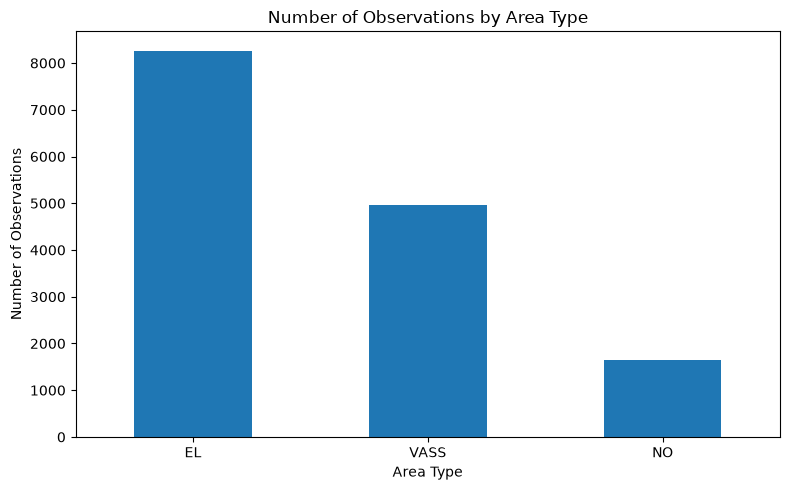

In [50]:
# Count observations for each geographical area type
area_type_counts = df["area_type"].value_counts()

plt.figure(figsize=(8, 5))
area_type_counts.plot(kind="bar")

plt.title("Number of Observations by Area Type")
plt.xlabel("Area Type")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Area number

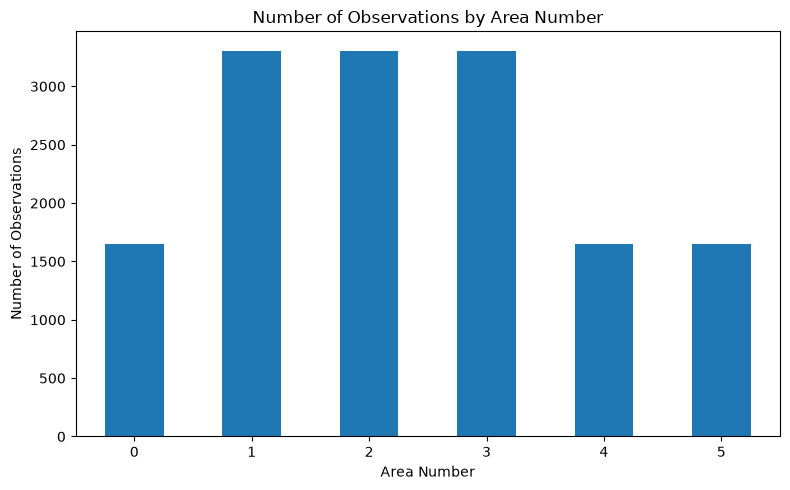

In [51]:
# Count observations for each area identifier
area_number_counts = df["area_number"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
area_number_counts.plot(kind="bar")

plt.title("Number of Observations by Area Number")
plt.xlabel("Area Number")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### ISO year

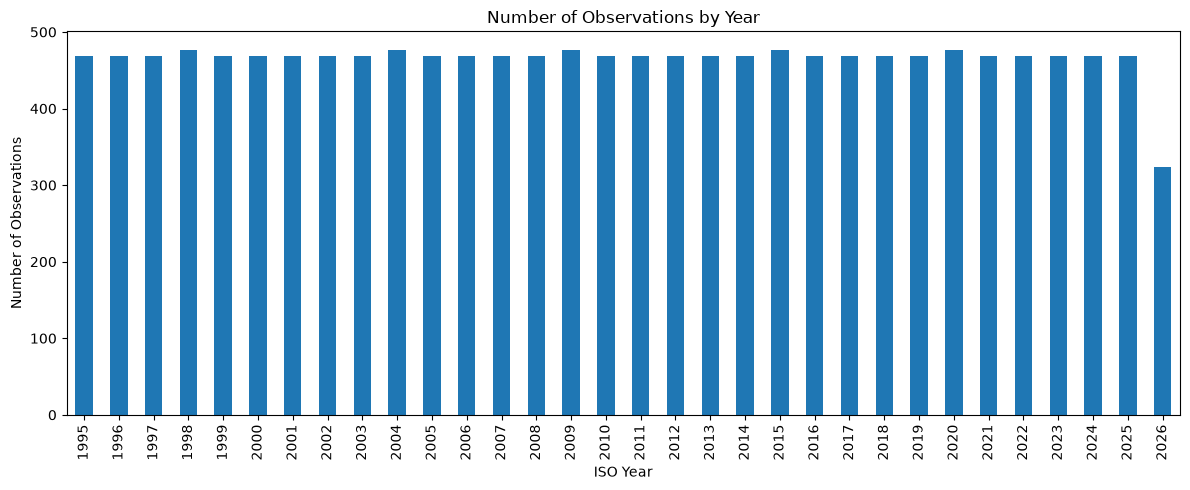

In [52]:
# Count observations available for each ISO year
year_counts = df["iso_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
year_counts.plot(kind="bar")

plt.title("Number of Observations by Year")
plt.xlabel("ISO Year")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

#### ISO week

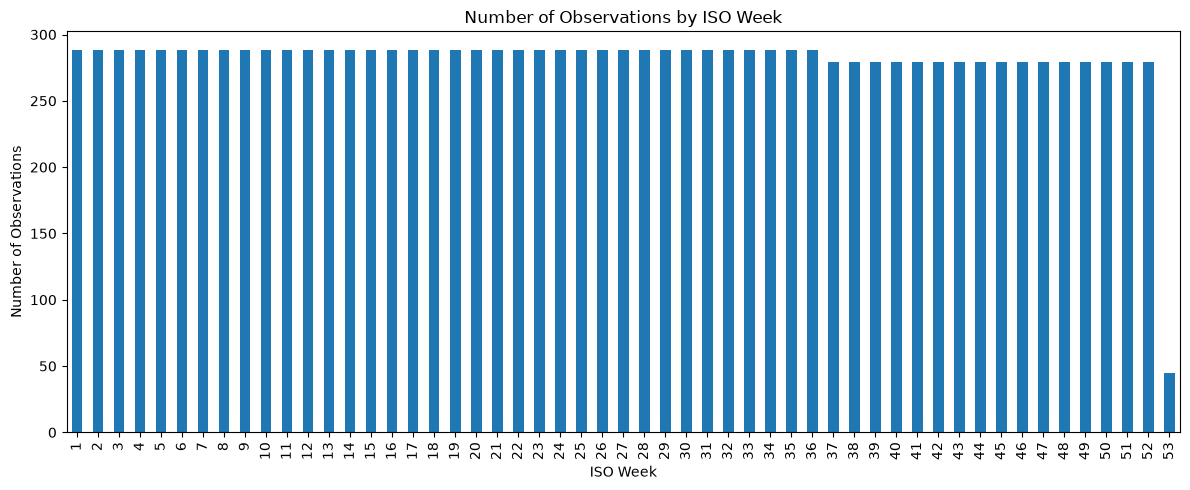

In [53]:
# Examine how observations are distributed across ISO weeks
week_counts = df["iso_week"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
week_counts.plot(kind="bar")

plt.title("Number of Observations by ISO Week")
plt.xlabel("ISO Week")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.show()

#### Date

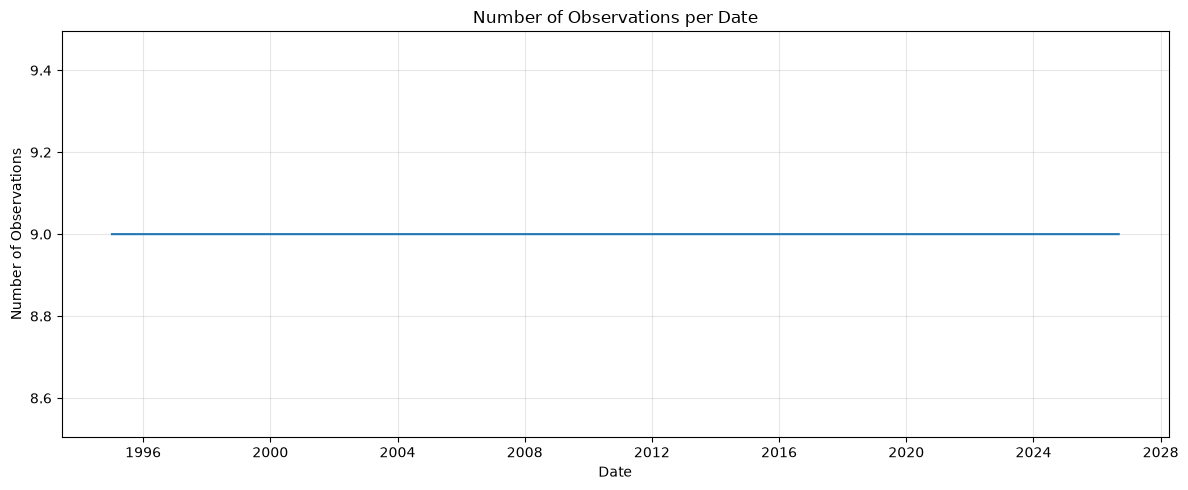

In [54]:
# Count the number of observations recorded on each date
date_counts = df["date"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(date_counts.index, date_counts.values)

plt.title("Number of Observations per Date")
plt.xlabel("Date")
plt.ylabel("Number of Observations")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Next publication date

`next_publication_date` is an administrative metadata field rather than a 
reservoir measurement. The original dataset also uses `0001-01-01` as a 
placeholder for unavailable publication dates. These placeholders were treated 
as missing values during preprocessing, and the variable is therefore not 
included in the time-series analysis.

## 7. Combined Plot

The numerical reservoir measurements have different units and scales, which makes a direct comparison difficult. To make the time-series patterns comparable, the variables are normalised to a common scale from 0 to 1.

Only meaningful reservoir measurements are included. Identifier, categorical and administrative variables are excluded from the combined plot.

In [55]:
# Select measurements that vary over time and can be meaningfully compared.
# Capacity is excluded because national capacity is constant in the dataset.
combined_columns = [
    "fill_level",
    "stored_energy_twh",
    "previous_week_fill_level",
    "change_in_fill_level",
]

In [56]:
# Create a copy containing only the measurements used in the combined plot
normalized_data = norway_data[combined_columns].copy()

# Min-max normalisation:
# each variable is transformed to values between 0 and 1
for column in combined_columns:
    minimum = normalized_data[column].min()
    maximum = normalized_data[column].max()

    normalized_data[column] = (
        normalized_data[column] - minimum
    ) / (maximum - minimum)

normalized_data.head()

,fill_level,stored_energy_twh,previous_week_fill_level,change_in_fill_level
5,0.544098,0.544098,0.727714,0.000000
14,0.511173,0.511173,0.544109,0.439810
23,0.485800,0.485800,0.511204,0.461793
32,0.450329,0.450329,0.485808,0.432379
41,0.414707,0.414707,0.450310,0.432013


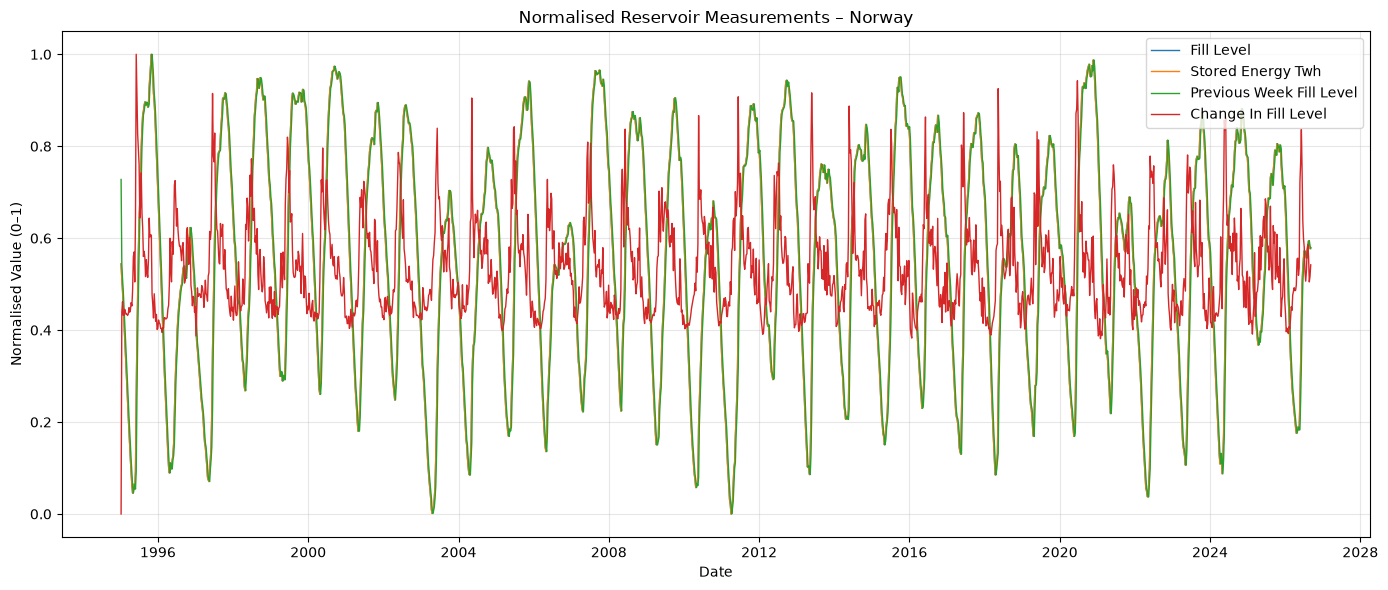

In [57]:
# Plot all normalised measurements together to compare their patterns over time
plt.figure(figsize=(14, 6))

for column in combined_columns:
    plt.plot(
        norway_data["date"],
        normalized_data[column],
        label=column.replace("_", " ").title(),
        linewidth=1
    )

plt.title("Normalised Reservoir Measurements – Norway")
plt.xlabel("Date")
plt.ylabel("Normalised Value (0–1)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The normalised plot shows that `fill_level`, `stored_energy_twh`, and 
`previous_week_fill_level` follow very similar patterns over time. 
This is expected because stored energy is closely related to reservoir fill level.

The `change_in_fill_level` variable behaves differently, as it represents 
weekly changes rather than the absolute level of the reservoirs.

`capacity_twh` is not included in the combined plot because it is constant 
for the national observations and therefore does not provide a meaningful 
time-series pattern.

## 8. Streamlit Application

## 9. AI Usage

## 10. Work Log